In [1]:
import numpy as np 
import pandas as pd
import scipy.io as sio
from timeit import default_timer

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2

# the following code make plots look better
def plot_prettier(dpi=150, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

<center>

# <font color='darkblue'>ASTR 21100</font>

## <font color='darkblue'>"Computational Techniques in Astrophysics"</font>
    
## <font color='darkblue'>Function approximation methods in many dimensions: </font>
 
## <font color='darkblue'>Introduction to non-neural network Machine Learning methods</font>

<p>
<p>
<center>
<img width=800 src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0a/Flammarion_Colored.jpg/1920px-Flammarion_Colored.jpg"></img>

### <font color='blue'>Application of ML methods in practice</font>

* Data preprocessing. Scaling, if needed. 


* Feature importance analysis/dimensionality reduction. Feature selection.


* Experiment with different methods. Find the method that provides the highest accuracy for acceptable computational time. 

### <font color='blue'>Specific example: classification of sources into quasars, stars, and galaxies in the Sloan Digital Sky Survey (SDSS)</font>


### <font color='blue'>Background </font>

One important and commonly encountered task in current and future astronomical surveys is separation of the sources detected in images into different classes, such as stars, galaxies, quasars, etc. Large sizes of modern data sets preclude visual classification and require an automated algorithm for such classification. 


In this notebook we illustrate how source classification can be done using machine learning (ML) methods. Specifically, we will use data from the 15th data release (DR 15) of the Sloan Digital Sky Survey (SDSS) to classify objects into  three categories (quasar, star, galaxy) based on their photometric properties: magnitudes measured in different filters $u$, $g$, $r$, $i$, $z$, and various other quantities.

In some cases we can also use the redshift information because redshift reflects an approximate distance to an object.  However given that redshift is not available for all sources, its use will be minimized. 

In [2]:
# Import the 
sdss_table = pd.read_csv("https://astro.uchicago.edu/~andrey/classes/a211/data/stars_galaxies_qso_dr15.csv")
sdss_table.head()


,objid,ra,dec,u,g,r,i,z,specobjid,class,redshift
0,1237646798137787517,121.802126,0.855476,25.02634,21.90814,20.17926,19.22341,18.68446,5342652717419438080,GALAXY,0.504717
1,1237646798137787833,121.748271,0.891010,23.74677,22.75365,21.10284,20.06169,19.50690,5342652167663624192,GALAXY,0.579273
2,1237646798137788079,121.708487,0.874751,23.15607,22.95075,20.89328,19.71096,19.10471,5342651617907810304,GALAXY,0.772647
3,1237646798137852371,121.820752,0.931990,19.37035,17.34262,16.35286,15.92400,15.58903,5342663162779901952,GALAXY,0.101993
4,1237646798137852646,121.910430,0.896389,23.42736,22.81119,20.27570,19.14886,18.67588,5342662613024088064,GALAXY,0.585733


In [3]:
import PIL, urllib 

def legacy_viewer_url(ra, dec, zoom=None, width=400, height=400, pixscale=1, layer='ls-dr9'):
    '''
    Construct URL to get an image from the Legacy Survey viewer for a quick check
    '''
    base_url = 'https://www.legacysurvey.org/viewer/jpeg-cutout?'
    if zoom is not None: 
        url = base_url + f'ra={ra}&dec={dec}&zoom={zoom}&layer={layer}'
    else: 
        url = base_url + \
        f'ra={ra}&dec={dec}&zoom={zoom}&pixscale={pixscale}&width={width}&height={height}&layer={layer}'
    return url


from matplotlib.colors import LogNorm

def plot_image(image, minsubtract=True, title=None, fontsize=10, figsize=(10,10)):
    '''
    Plots an image using pixels in the input 2d list or NumPy array image
    '''
    if minsubtract:
        # Determine the minimum of image pixel values using "list comprehension"
        #imin = min([min(row) for row in image]) # min() is a built-in function for finding minimum of a simple list
        # Subtract the minimum from each image pixel using nested list comprehension
        #image_ = [[(x - imin) for x in row] for row in image]
        image_ = image - image.min()
    else:
        image_ = image
        
        
    # Now plot the image with Matplotlib
    # Define a single panel plot of a given size
    fig, ax = plt.subplots(1,1, figsize=figsize)
    # Display image in list image using 'gray' colormap on a log stretch
    ax.imshow(image_, cmap='gray', norm=LogNorm(), origin='lower') 
    _ = ax.axis('off') # Do not plot axis ticks
    # Display plot title with the specified string
    if title is not None: ax.set_title(title, fontsize=fontsize)
    plt.show() # Show the plot
    
    
def plot_source_cutout(ra, dec,  src_type=None, width=300, height=300, pixscale=0.1, 
                       zoom=None, layer='sdss', fontsize=9, figsize=(3,3)):
    """
    
    Parameters:
        ra, dec: floats, RA and DEC of the center of the image
        width, height: ints, width and hight of the image in pixels
        pixscale: float, the scale of pixel in arcseconds, ignored if zoom is not None
        zoom: int, legacy survey zoom level, default is None (in this case pixscale is used)
        layer: data layer to query for image, possible choices are 
        'sdss', 'ls-dr9' (Legacy survey DR9), 'ls-dr10' (Legacy survey DR10)
        
    """
    
    url = legacy_viewer_url(ra, dec,  width=width, height=height, pixscale=pixscale, zoom=zoom, layer=layer)
    try: 
        image = np.array(PIL.Image.open(urllib.request.urlopen(url)))
    except:
        print('Server error!')
        return 
    if src_type is None: 
        title = f'RA = {ra:.3f};  DEC = {dec:.3f}'
    else:
        title = src_type + ' ' + f'RA = {ra:.3f};  DEC = {dec:.3f}'
    plot_image(image, title=title, fontsize=fontsize, figsize=figsize)
    

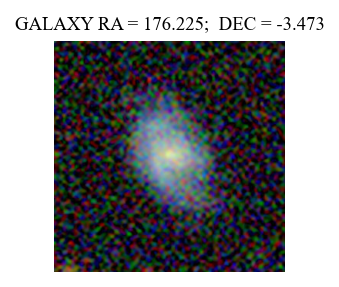

In [31]:
class_obs = sdss_table['class']

# define class to plot: 'QSO', 'GALAXY' or 'STAR'
plot_class = 'GALAXY' 
ras = sdss_table['ra'][class_obs==plot_class].to_numpy()
decs = sdss_table['dec'][class_obs==plot_class].to_numpy()

irnd = np.random.randint(0, ras.size)
plot_source_cutout(ras[irnd], decs[irnd], src_type=plot_class, figsize=(2,2))


In [5]:
# Get the magnitudes
u, g, r, i, z = sdss_table['u'], sdss_table['g'], sdss_table['r'], sdss_table['i'], sdss_table['z']
redshift = sdss_table['redshift']
class_label = np.zeros(len(class_obs)) 


Now change the class of objects to something numerical: "GALAXY" = 0, "STAR" = 1, "QSO"=2

In [7]:
class_label[class_obs=="STAR"] = 1 
class_label[class_obs=="QSO"] = 2 


Prepare data by applying some quality cuts. For example, by removing all sources with magnitudes smaller (i.e. brighter) than -10. 

In [8]:
cuts = (u > -10.) & (g > -10.) & (r > -10.0 )& (i > -10.0) & (z > -10.0)

u, g, r, i, z = u[cuts], g[cuts], r[cuts], i[cuts], z[cuts]

class_label = class_label[cuts]
print('{:d} sources left after cuts.'.format(len(u)))


299908 sources left after cuts.


Let's see how many we have from each category.

In [9]:
print(len(u[class_label==0]))
print(len(u[class_label==1]))
print(len(u[class_label==2]))


184535
73228
42145


So, we have 184535 galaxies, 73228 stars and 42145 quasars. The number of objects in different categories in the sample is quite different. This is called *class imbalance*. 
We will need to be careful about this class imbalance during analysis...


We can use magnitudes to define "colors" of sources, which are defined as differences of magnitudes in different bands. All possible colors we can form are $u-g$, $u-r$, $u-i$, $u-z$, $g-r$, $g-i$, $g-z$, $r-i$, $r-z$.  

We can also form ratios of magnitudes, which are another measure of relative brightness of objects in different wavelength ranges of the spectrum: $u/g$, $u/r$, $u/i$, $u/z$, $g/r$, $g/i$, $g/z$, $r/i$, $r/z$.

In [10]:
# define colors 
u_g, u_r, u_i, u_z = u-g, u-r, u-i, u-z
g_r, g_i, g_z, r_i, r_z = g-r, g-i, g-z, r-i, r-z

# magnitude ratios
u_ov_g, u_ov_r, u_ov_i, u_ov_z  = u/g, u/r, u/i, u/z 
g_ov_r, g_ov_i, g_ov_z, r_ov_i, r_ov_z = g/r, g/i, g/z, r/i, r/z


Now create what's called an *feature matrix* - array that actually will be input into a machine learning function.

In [11]:
n_feat = 23

# initialize feature matrix
X_feat = np.zeros([u.size,n_feat])

# define feature matrix
for i, f in enumerate([u, g, r, i, z, u_g, u_r, u_i, u_z, 
                       g_r, g_i, g_z, r_i, r_z, 
                       u_ov_g, u_ov_r, u_ov_i, u_ov_z, 
                       g_ov_r, g_ov_i, g_ov_z, r_ov_i, r_ov_z]):
    X_feat[:,i] = f
    

For certain classifier methods that rely on distance estimates it is desirable that the range that values of different parameters span are similar. In general, spaces of parameters with different meaning and units are "non-metric" and if scales of parameters are very different distances may be nearly meaningless. 

For this reason before classification ranges of each variable are rescaled to a similar range. In <tt>scikit-learn</tt> there is a special class for this called <tt>StandardScaler</tt>. 

Standardization of this dataset can be done as follows. 

In [12]:
from sklearn.preprocessing import StandardScaler

X_ft_stand = StandardScaler().fit_transform(X_feat)
print(X_ft_stand.shape)

for i in range(X_ft_stand.shape[1]):
    print(X_ft_stand[:,i].min(), X_ft_stand[:,i].max())
    

(299908, 23)
-4.195394815633533 4.012917644347961
-4.113739662281788 4.784524849009505
-4.34514143664987 6.625511376485876
-4.46061069857643 6.4895615348209965
-4.5527913975644845 6.215162367816681
-12.128889027861788 12.017422876500222
-10.49410617557476 8.678652155366485
-10.353438645345406 7.499537906101932
-7.131245579333077 6.847263661611965
-19.96089269058936 18.41051627872138
-14.396366122474188 10.580563200387614
-10.457844300722332 10.06983246254999
-28.422933011573278 28.132222702624766
-20.04667038477462 21.37854929259343
-8.949340161075606 16.41234115319525
-7.237059510692263 11.995675270147403
-7.534308501371773 10.362460818712849
-5.338187420082557 10.010310908642827
-14.287186536396517 25.88935464253868
-10.476215389200432 16.584040506239656
-7.70693727315663 12.407447504281835
-20.374672618591607 35.74687892685006
-14.108889499311104 26.306927337241905


In [53]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

feature_names = np.array(['u', 'g', 'r', 'i', 'z', 'u_g', 'u_r', 'u_i', 'u_z', 
                       'g_r', 'g_i', 'g_z', 'r_i', 'r_z', 
                       'u_ov_g', 'u_ov_r', 'u_ov_i', 'u_ov_z', 
                       'g_ov_r', 'g_ov_i', 'g_ov_z', 'r_ov_i', 'r_ov_z'])

#Select top  features based on mutual info regression for different k 
for k in range(3,14): 
    selector = SelectKBest(mutual_info_regression, k=k)
    selector.fit(X_ft_stand, class_label)
    isel = selector.get_support()
    print(k, feature_names[isel])
    

3 ['g_ov_i' 'r_ov_i' 'r_ov_z']
4 ['g_ov_i' 'g_ov_z' 'r_ov_i' 'r_ov_z']
5 ['r_i' 'g_ov_i' 'g_ov_z' 'r_ov_i' 'r_ov_z']
6 ['g_i' 'r_i' 'g_ov_i' 'g_ov_z' 'r_ov_i' 'r_ov_z']
7 ['g_i' 'g_z' 'r_i' 'g_ov_i' 'g_ov_z' 'r_ov_i' 'r_ov_z']
8 ['g_i' 'g_z' 'r_i' 'g_ov_r' 'g_ov_i' 'g_ov_z' 'r_ov_i' 'r_ov_z']
9 ['g_i' 'g_z' 'r_i' 'r_z' 'g_ov_r' 'g_ov_i' 'g_ov_z' 'r_ov_i' 'r_ov_z']
10 ['g_r' 'g_i' 'g_z' 'r_i' 'r_z' 'g_ov_r' 'g_ov_i' 'g_ov_z' 'r_ov_i'
 'r_ov_z']
11 ['g_r' 'g_i' 'g_z' 'r_i' 'r_z' 'u_ov_z' 'g_ov_r' 'g_ov_i' 'g_ov_z'
 'r_ov_i' 'r_ov_z']
12 ['g_r' 'g_i' 'g_z' 'r_i' 'r_z' 'u_ov_i' 'u_ov_z' 'g_ov_r' 'g_ov_i'
 'g_ov_z' 'r_ov_i' 'r_ov_z']
13 ['u_i' 'g_r' 'g_i' 'g_z' 'r_i' 'r_z' 'u_ov_i' 'u_ov_z' 'g_ov_r' 'g_ov_i'
 'g_ov_z' 'r_ov_i' 'r_ov_z']


The cell above lists the most important parameters for a given specified number of parameters. This is not intuitive, but we can see that ratios of magnitude are more important than colors. 

As expected magnitudes are not important, because sources of different types can have magnitudes in similar ranges. Colors and magnitude ratios, however, are important because different sources have different spectra which is reflected in different ratios of magnitudes and their differences (colors). 

Results obtained here are similar but not identical to the feature importance analysis using Random Forest classifier below. 

### <font color='blue'>Split into training and test samples</font>


In [14]:
from sklearn.model_selection import train_test_split

X_ft_stand_r = X_ft_stand[:100000,:]
class_label_r = class_label[:100000]

X_train, X_test, y_train, y_test = train_test_split(X_ft_stand_r, class_label_r, train_size = 0.80, random_state = 42)


### <font color='blue'>$k$-th nearest neighbor (kNN) algorithm</font>


First, let's consider the k-nearest neigbor algorithm. This algorithm finds k nearest neigbors in the parameter space (in this case $28^2=784$-dimensional space) in the training sample for a given test sample and returns average result over these neighbors. 

Contribution of each neighbor is weighted inversely proportional to its distance from the test 
sample. Thus, this algorithm identifies class by estimating average class density in a given location using a kernel. It is thus similar to the kernel-density estimate method for regression and density estimation. 


    
<p>
<center>
<img width=600 src="https://www.analyticsvidhya.com/wp-content/uploads/2014/10/K-judgement.png"></img>

kNN definition of boundary between two classes of objects evolving as the size of the training sample increases. The true boundary is shown by the dashed line. 

<p>
<center>
<img width=400 src="https://paulvanderlaken.files.wordpress.com/2020/01/knn.gif"></img>

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

tstart = default_timer()
# define classifier object
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
# train classifier using the training data
knn.fit(X_train, y_train)

# predict classes for test data
ypred_knn = knn.predict(X_test)
print("Nearest neighbor classifier took %.2f sec"%(default_timer()-tstart))

# estimate classification accuracy of test data using correct answers for it
acc_knn = accuracy_score(y_test, ypred_knn)
print(f"nearest neighbors accuracy = {acc_knn:.3f}")


Nearest neighbor classifier took 1.49 sec
nearest neighbors accuracy = 0.902


However, this is accuracy for all categories combined. What if we want to know the accracy with which say galaxies were classified? 


### <font color='blue'> Confusion matrix</font> 

This analysis is usually done using what's called ***confusion matrix***, which shows both the accuracy of classification of sources in each individual category (the fraction of successful classifications) in the diagonal elements and specific mis-classification fraction between different categories in the off-diagonal elements.

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns # to plot the confusion matrix prettier

def conf_matrix(y_test, y_pred, class_names=None): 
    """
    helper function computing confusion matrix
    """
    conf_mat = confusion_matrix(y_test, y_pred).T
    conf_mat = conf_mat.astype(float)

    # normalize confusion fraction 
    for i in range(len(class_names)):
        conf_mat[i,:] /= float(np.sum(conf_mat[i,:])) 

    return conf_mat

def plot_confusion_matrix(y_test, ypred, class_names = ['galaxy', 'star', 'quasar'], 
                          title=None, figsize=(3,3)):
    conf_mat = conf_matrix(y_test, ypred_knn, class_names=class_names)

    plt.figure(figsize = figsize)
    if title is not None: 
        plt.title(title, fontsize=10)
    sns.heatmap(conf_mat.T, square = True, annot=True, fmt='.3f', cmap='Blues', cbar=False, 
               xticklabels= class_names,
               yticklabels= class_names)

    plt.xlabel('true label')
    plt.ylabel('predicted label')
    plt.show()

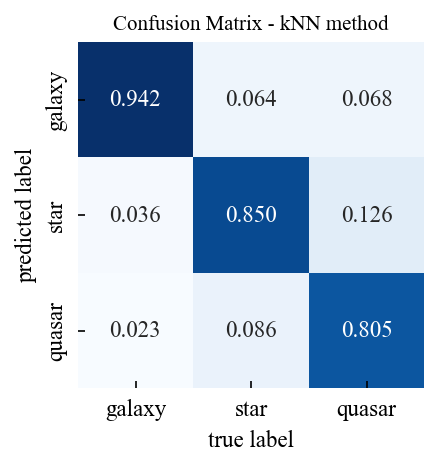

In [19]:
plot_confusion_matrix(y_test, ypred_knn, title='Confusion Matrix - kNN method')


We can see that classification of galaxies is more accurate than the average classification accuracy for this sample (94 %). 

This is because galaxies have very different colors and magnitude ratios from stars and quasars, while some stars and quasars have similar magnitude ratios and colors.  

Even galaxies get confused with stars and quasars in 3.6 and 2.5% of cases. 

### <font color='blue'>Support vector machine (SVM)</font>
        
<p>
<center>
    <img width=600 src="https://miro.medium.com/max/700/0*BsfFSbU5IZiEghFH.png"></img>

The <a href="http://scikit-learn.org/stable/modules/svm.html">support vector machine (SVM)</a> classification algorithm is a supervised ML method that uses training data to construct linear (i.e. using hyperplanes) or nonlinear (curved hyper-surfaces) to separate classes/clusters. The hyperplanes or hypersurfaces are characterized by associated "support vectors" (hence the name of this method). These vectors are constructed in such a way that the planes/surfaces that "touch" objects of particular class are maximally separated. 
    
    
Details are beyond the scope of this introduction, but the idea is illustrated in 2D in the figure below.    

$$y_j(\mathbf{w}\cdot\mathbf{x}_j + b) = {\rm sign}(\mathbf{w}\cdot\mathbf{x}_j + b)=\begin{cases}+1,\ \ {\rm magenta\ ball}\\
-1, \ \ {\rm green\ ball}\end{cases}$$

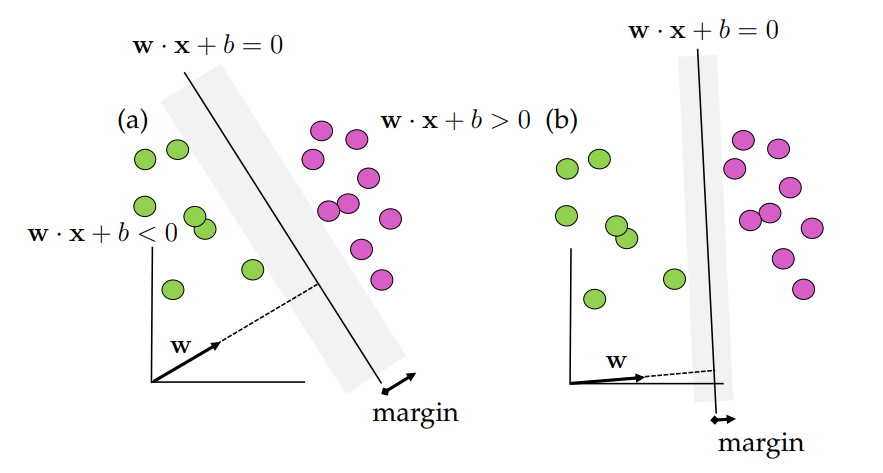

Illustration in 3D:

<center>
<img width=500 src="https://miro.medium.com/max/600/0*MgG8zoCB6CY4Fa19.gif"></img>

### <font color='blue'>Support vector machines (SVM) with a nonlinear kernel</font>


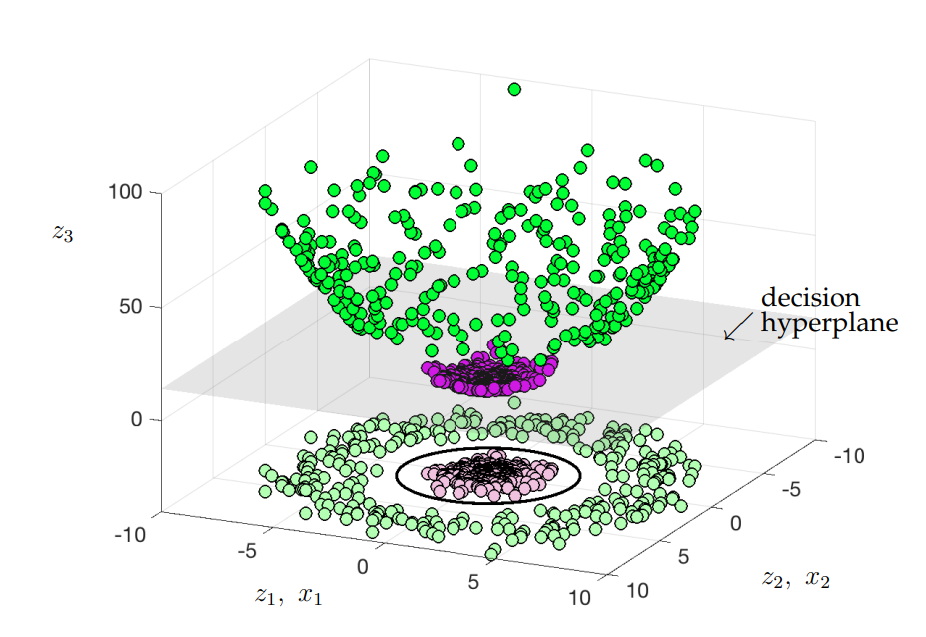

When original data is not separated well by a hyperplane, as in the examples below, one can transform the data values using a nonlinear transformation, so that transformed values can be separated by a hyperplane. This is done in the SVM variants with nonlinear kernel. One can either think about this as transformation of variables or transforing hyperplane into hypersurface. 
    
Adoped from <a href="https://arxiv.org/abs/1904.07248">"Machine Learning in Astronomy: a practical overview"</a> by D. Baron
    
In this example, instead of hyperplane, an oval surface is used to seprate different groupings. 


Boundary determined with the nonlinear SVM method as the training sample size increases. The true boundary is shown by the dashed line. 

<p>
<center>
<img width=400 src="https://paulvanderlaken.files.wordpress.com/2020/01/svm.gif"></img><center>

</center>

The cell below runs a very long time. 

In [58]:
from sklearn.svm import SVC

tstart = default_timer()
svc = SVC(gamma=0.007289, C=2.8284, kernel='rbf')
svc.fit(X_train, y_train)
print("tuned SVM took %.2f sec"%(default_timer()-tstart))

ypred_svm = svc.predict(X_test)
acc_svm = accuracy_score(y_test, ypred_svm)

print(f"tuned SVM accuracy = {acc_svm:.3f}")


tuned SVM took 113.25 sec
tuned SVM accuracy = 0.880


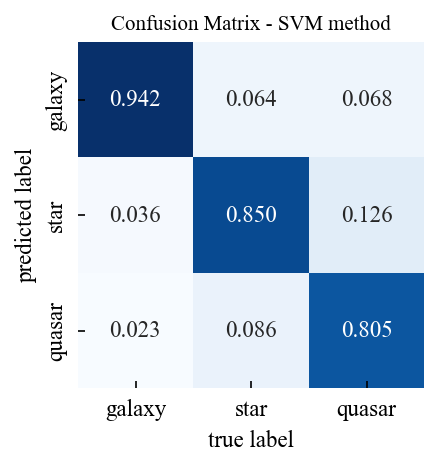

In [59]:
plot_confusion_matrix(y_test, ypred_svm, title='Confusion Matrix - SVM method')


###  <font color='blue'>Random Forest Classifier</font>

<img  src="https://www.simplilearn.com/ice9/free_resources_article_thumb/decision-tree-random-forest-algorithm.jpg"></img>

Tree construction can be done in $N\log_2 N$ operations and is much faster than neighbor search or support vector construction. The algorithm accuracy, however, is usually comparable to the accuracy of the more expensive methods described above. 



In [60]:
# We'll create a KDTree class which will recursively subdivide the
# space into rectangular regions.  Note that this is just an example
# and shouldn't be used for real computation; instead use the optimized
# code in scipy.spatial.cKDTree or sklearn.neighbors.BallTree
class KDTree:
    """Simple KD tree class"""

    # class initialization function
    def __init__(self, data, mins, maxs):
        self.data = np.asarray(data)

        # data should be two-dimensional
        assert self.data.shape[1] == 2

        if mins is None:
            mins = data.min(0)
        if maxs is None:
            maxs = data.max(0)

        self.mins = np.asarray(mins)
        self.maxs = np.asarray(maxs)
        self.sizes = self.maxs - self.mins

        self.child1 = None
        self.child2 = None

        if len(data) > 1:
            # sort on the dimension with the largest spread
            largest_dim = np.argmax(self.sizes)
            i_sort = np.argsort(self.data[:, largest_dim])
            self.data[:] = self.data[i_sort, :]

            # find split point
            N = self.data.shape[0]
            N2 = int(N/2)
            N21 = int(N/2 - 1)
            split_point = 0.5 * (self.data[N2, largest_dim]
                                 + self.data[N21, largest_dim])

            # create subnodes
            mins1 = self.mins.copy()
            mins1[largest_dim] = split_point
            maxs2 = self.maxs.copy()
            maxs2[largest_dim] = split_point

            # Recursively build a KD-tree on each sub-node
            self.child1 = KDTree(self.data[N2:], mins1, self.maxs)
            self.child2 = KDTree(self.data[:N2], self.mins, maxs2)

    def draw_rectangle(self, ax, depth=None):
        """Recursively plot a visualization of the KD tree region"""
        if depth == 0:
            rect = plt.Rectangle(self.mins, *self.sizes, ec='k', fc='none')
            ax.add_patch(rect)

        if self.child1 is not None:
            if depth is None:
                self.child1.draw_rectangle(ax)
                self.child2.draw_rectangle(ax)
            elif depth > 0:
                self.child1.draw_rectangle(ax, depth - 1)
                self.child2.draw_rectangle(ax, depth - 1)

def plot_kdtree(X, kdt, xlim=[], ylim=[]):
    #------------------------------------------------------------
    # Plot four different levels of the KD tree
    fig = plt.figure(figsize=(3, 3))
    fig.subplots_adjust(wspace=0.1, hspace=0.15,
                        left=0.1, right=0.9,
                        bottom=0.05, top=0.9)

    for level in [1,2,3,4]:
        lev = level
        if lev > 4 : lev = 4
        ax = fig.add_subplot(2, 2, lev, xticks=[], yticks=[])
        ax.scatter(X[:, 0], X[:, 1], s=1)
        kdt.draw_rectangle(ax, depth=level - 1)

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title('level %i' % (level-1), fontsize=9)

    # suptitle() adds a title to the entire figure
    #fig.suptitle('$k$d-tree example')
    plt.show()
    
def sample_D_gaussian(mean, covar, N, D):
    """
    sample N numbers from a Gaussian in D dimensions
    mean = vector of mean values
    covar = matrix of covariances
    """
    if np.isscalar(covar):
        # assume isotropic
        return np.random.normal(loc=mean, scale=np.sqrt(covar), size=(N,D))
    # otherwise use covariance matrix
    covar = np.array(covar)
    u, s, v = np.linalg.svd(covar)
    # generate a usual Gaussian
    x = np.random.normal(size = (N,D))
    # rotate it according to align with the covariance matrix
    return mean + np.dot(u, (x * s).T).T

    
def generate_3clusters(N=1000, amps=[0.6, 0.2, 0.2], means=[(3., 4.),(7.,9.),(10.5,4.)],
                         covs = [np.array([[1.,-0.5],[-0.5,1.]]),np.array([[1., 0.], [0., 1.]]), 
                                 np.array([[1.,0.5],[0.5,1.]])]):

    # number of points in each cluster
    ncl = np.random.multinomial(N, amps)
    x, labs = [], []
    for i in range(3): 
        cluster = sample_D_gaussian(means[i], covs[i], ncl[i], 2)
        for c in cluster:
            x.append(c)
            labs.append(i)
    return np.array(x, dtype='float'), np.array(labs, dtype='int')

# generate training data
xtr, labtr = generate_3clusters(means = [(3., 4.), (7., 9.), (6.5, 4.)])
# generate test data
xt, labt = generate_3clusters(means = [(3., 4.), (7., 9.), (6.5, 4.)])

def plot_3_clusters(x, y, labels):
    # plot
    colors = np.array(['b','r','g']) 
    plt.figure(figsize=(3,3))
    plt.scatter(x, y, marker='.', s=70.0, 
                edgecolor='black', alpha=0.9, c=colors[labels])
    plt.show()

In this illustration, the decision boundary along each dimension is simply the median value of sample coordinates. In practice, these methods try to put decision boundary in such a way that individual classes are maximally separated. This requires search for the best dimension to split and the best location within each dimension to split. 

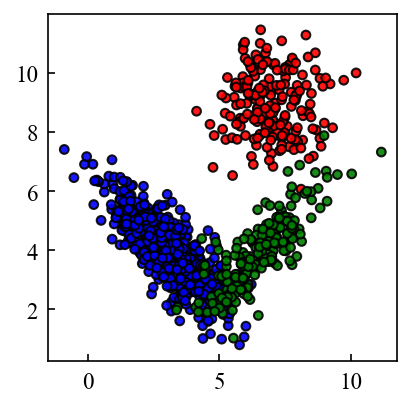

In [61]:
plot_3_clusters(xtr[:,0], xtr[:,1], labtr)


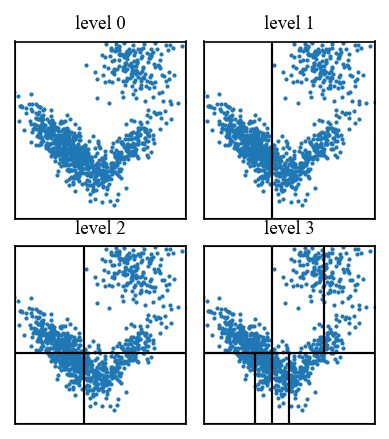

In [62]:
#  construct k-d tree
kdt = KDTree(xtr, [0, 0], [10, 10])
plot_kdtree(xtr, kdt, xlim=[0,10], ylim=[0,10])


In [63]:
# a faster version is available in scipy.spatial
from scipy.spatial import cKDTree

ckdt = cKDTree(X)

Boundary between two classes determined by tree classifier as the size of the training sample increases. The true boundary is shown by the dashed line. 


<p>
<center>
<img width=400 src="https://paulvanderlaken.files.wordpress.com/2020/01/tree.gif"></img>

###  <font color='blue'>Random Forest Classifier uses an ensemble of trees with randomly chosen order of dimensions to split</font>

Classification for a given location in the feature space is determined by the classification that most trees in the ensemble give for it. 
Random forest classifier boundary between the two classes as the size of the training sample increases. The true boundary is shown by the dashed line. 

<center>
<img width=400 src="https://paulvanderlaken.files.wordpress.com/2020/01/randomforest.gif"></img>

In [33]:
from sklearn.ensemble import RandomForestClassifier

# create an instance of the random forest classifier
rf = RandomForestClassifier(n_estimators=100)

tstart = default_timer()
rf.fit(X_train, y_train) # train the classifier using training sample
print(f'finished in {default_timer()-tstart:.2f} sec')

# now predict now on the test set
ypred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, ypred_rf)
print(f'classification accuracy for test sample is {100.*acc_rf:.2f} %')


finished in 139.16 sec
classification accuracy for test sample is 90.61 %


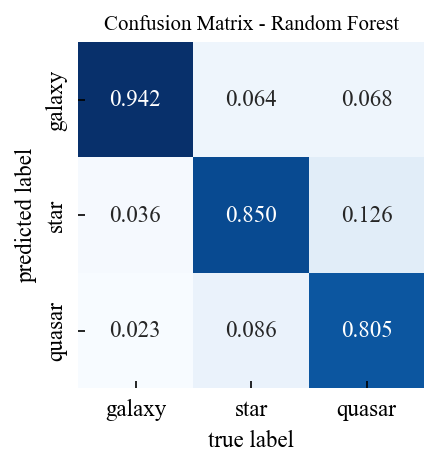

In [20]:
plot_confusion_matrix(y_test, ypred_rf, title='Confusion Matrix - Random Forest')


### <font color='blue'>Feature importance is provided automatically from the tree structure</font>

We can also examine ***feature importance*** - the relative importance of different source properties that we used for successful classification. 

This is particularly useful aspect of the Random Forest method, because when decision trees are constructed in this method, the splits are performed along the dimensions which result in maximal separation of classes. So the trees in their structure carry information about the order in which dimensions were split and thus about relative importance of these dimensions in separating sources into different classes.

This information is easily accessible, once a Random Forest method is trained, as shown below. 

In [161]:
importances = rf.feature_importances_

indices = np.argsort(importances)[::-1]

# Print the feature ranking
print('feature ranking:')
print('-'*15)
      
for f in range(X_train.shape[1]):
    print(f"{f+1}. {feature_names[indices[f]]}, importance score = {importances[indices[f]]:.5f}")
    

feature ranking:
---------------
1. r_ov_z, importance score = 0.09731
2. r_ov_i, importance score = 0.09422
3. r_i, importance score = 0.08164
4. r_z, importance score = 0.07580
5. g_ov_z, importance score = 0.07058
6. g_z, importance score = 0.05038
7. g_ov_i, importance score = 0.04261
8. g_ov_r, importance score = 0.04261
9. g_i, importance score = 0.04261
10. u_ov_i, importance score = 0.04073
11. u_g, importance score = 0.03740
12. u_r, importance score = 0.03683
13. u_ov_g, importance score = 0.03532
14. g_r, importance score = 0.03367
15. u_ov_r, importance score = 0.03100
16. u_ov_z, importance score = 0.02748
17. u_i, importance score = 0.02592
18. i, importance score = 0.02509
19. z, importance score = 0.02463
20. u_z, importance score = 0.02449
21. r, importance score = 0.02044
22. g, importance score = 0.02007
23. u, importance score = 0.01918


The most important are features >10, which correspond to (some) colors and magnitude ratios. Note, however, that not all colors and magnitude ratios are equally important. These results imply that we can try to only use properties that are important thereby reducing dimensionality of the problem and improving classification. 

We can also visualize relative feature importance in a histogram.

In [162]:
def plot_rf_importances(indices, importances, feature_names):
    # Plot the feature importances of the forest
    plt.figure(figsize=(5,2.5))
    plt.title("feature importances")
    plt.bar(feature_names[indices], importances[indices],
           color="slateblue",  align="center")
    plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
    plt.xlim([-1, X_train.shape[1]])

    plt.xlabel('feature name')
    plt.ylabel('feature importance')
    plt.show()

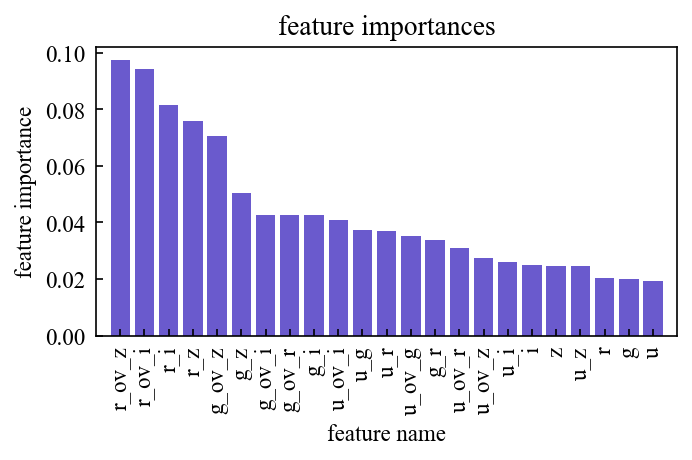

In [163]:
plot_rf_importances(indices, importances, feature_names)


### <font color='blue'>Extra Randomized Forest method and Gradient Boosted Trees</font>


In extra randomized trees, randomness goes one step further in the way splits are computed. As in random forests, a random subset of candidate features is used, but instead of looking for the most discriminative thresholds, thresholds are drawn at random for each candidate feature and the best of these randomly-generated thresholds is picked as the splitting rule.


Boundary between two classes determined by the Extra Randomized Forest method as the size of the training sample increases. The true boundary is shown by the dashed line. 

<center>
<img width=400 src="https://paulvanderlaken.files.wordpress.com/2020/01/xgboost.gif"></img>

In [170]:
from sklearn.ensemble import ExtraTreesClassifier

tstart = default_timer()
erf = ExtraTreesClassifier(min_samples_split=10, n_estimators=100)
erf.fit(X_train, y_train)

print(f'Extremely Randomized Forest finished in {default_timer()-tstart:.2f} sec')

ypred_erf = erf.predict(X_test)
acc_erf = accuracy_score(y_test, ypred_erf)
print(f'ERF classification accuracy for test sample is {100.*acc_rf:.2f} %')


Extremely Randomized Forest finished in 7.60 sec
ERF classification accuracy for test sample is 90.69 %


In [165]:
importances = erf.feature_importances_

indices = np.argsort(importances)[::-1]

# Print the feature ranking
print('feature ranking:')
print('-'*15)
      
for f in range(X_train.shape[1]):
    print(f"{f+1}. {feature_names[indices[f]]}, importance score = {importances[indices[f]]:.5f}")

feature ranking:
---------------
1. r_z, importance score = 0.06611
2. r_ov_z, importance score = 0.06512
3. g_ov_z, importance score = 0.06266
4. u_ov_z, importance score = 0.05812
5. g_z, importance score = 0.05064
6. u_r, importance score = 0.04853
7. r_i, importance score = 0.04729
8. g_ov_i, importance score = 0.04713
9. u_ov_r, importance score = 0.04650
10. u_z, importance score = 0.04511
11. u_i, importance score = 0.04454
12. u_ov_i, importance score = 0.04105
13. g_ov_r, importance score = 0.03973
14. g_i, importance score = 0.03898
15. r_ov_i, importance score = 0.03893
16. u_ov_g, importance score = 0.03674
17. g_r, importance score = 0.03583
18. u_g, importance score = 0.03574
19. z, importance score = 0.03537
20. i, importance score = 0.03138
21. g, importance score = 0.02941
22. u, importance score = 0.02828
23. r, importance score = 0.02681


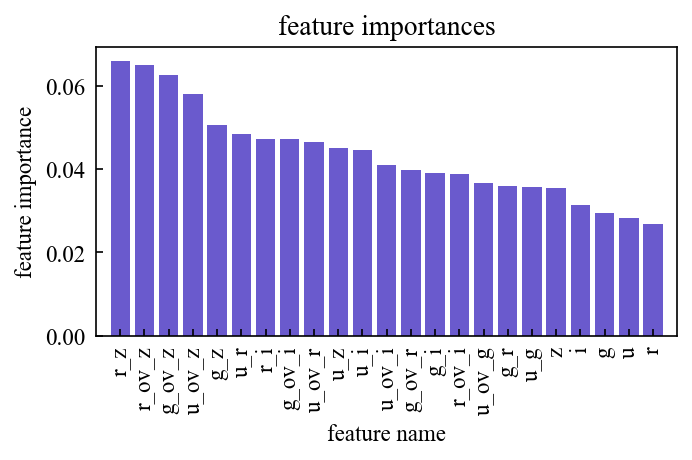

In [166]:
plot_rf_importances(indices, importances, feature_names)

### <font color='blue'>Hyper-parameter optimization</font> 
    

You may have noticed that RandomForestClassifier was initialized with a specific set of input parameters: for example <tt>n_estimators=100</tt>. Such parameters are called ***hyper-parameters*** of the method and results can depend on their choice. Thus, one often performs a search for the optimal parameters. 
    
Given that running ML methods is usually quite expensive, standard optimization methods would take too long generally. So often a simpler strategy is used, where just a few values of parameters are tried to see which works best. 
    
Such task is facilitated by scikit-learn's <tt>GridSearchCV</tt> function, which can be used with any method. Example of its use is shown below. 

***Note:*** cell below will take several minutes to complete.

In [169]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 150, 200],
              'min_samples_split': [5, 10, 15]}

erf = ExtraTreesClassifier(n_estimators=100)

grid = GridSearchCV(erf, param_grid, cv=3)

tstart = default_timer()
grid.fit(X_train, y_train)
print(f'completed in {default_timer()-tstart:.2f} sec')
print(' ')
print('best parameters are:')
print(grid.best_params_)

completed in 220.55 sec
 
best parameters are:
{'min_samples_split': 10, 'n_estimators': 100}


### <font color='blue'>Artificial Neural Nets</font>
    
Below is an example of using a relatively simple network with 3 hidden layers for this classification problem.
    
This will use tensorflow and keras packages, which you need to install to run this code. See [here](https://www.activestate.com/resources/quick-reads/how-to-install-keras-and-tensorflow/) for installation instructions. 

In [171]:
import tensorflow as tf
from tensorflow import keras
#from keras import to_categorical

y_train_cat = tf.keras.utils.to_categorical(y_train)
y_test_cat = tf.keras.utils.to_categorical(y_test)

Build the ANN model

In [198]:
model = keras.models.Sequential()
# add hidden layers
model.add(keras.layers.Dense(100, input_dim=23, activation='relu'))
model.add(keras.layers.Dense(70, input_dim=100, activation='relu'))
model.add(keras.layers.Dense(50, input_dim=70, activation='relu'))
model.add(keras.layers.Dense(30, input_dim=50, activation='relu'))
model.add(keras.layers.Dense(10, input_dim=30, activation='relu'))
# add output layer of 3 classes
model.add(keras.layers.Dense(units=3, activation='softmax'))
# construct networks with a given cost function and metric to be used
model.compile(loss='categorical_crossentropy', metrics=['accuracy'])

In [231]:
nepochs, batch_size = 10, 200
device = '/device:GPU:0'

tstart = default_timer()
with tf.device(device):
    model.fit(x=X_train, y=y_train_cat, epochs=nepochs, batch_size=batch_size, shuffle=True)
    
print(f'completed in {default_timer()-tstart:.2f} sec')


Epoch 1/10
400/400 [==============================] - 4s 10ms/step - loss: 0.2184 - accuracy: 0.9190
Epoch 2/10
400/400 [==============================] - 4s 11ms/step - loss: 0.2187 - accuracy: 0.9188
Epoch 3/10
400/400 [==============================] - 4s 11ms/step - loss: 0.2181 - accuracy: 0.9190
Epoch 4/10
400/400 [==============================] - 5s 12ms/step - loss: 0.2183 - accuracy: 0.9190
Epoch 5/10
400/400 [==============================] - 5s 13ms/step - loss: 0.2180 - accuracy: 0.9191
Epoch 6/10
400/400 [==============================] - 4s 10ms/step - loss: 0.2177 - accuracy: 0.9200
Epoch 7/10
400/400 [==============================] - 6s 14ms/step - loss: 0.2173 - accuracy: 0.9193
Epoch 8/10
400/400 [==============================] - 5s 12ms/step - loss: 0.2178 - accuracy: 0.9191
Epoch 9/10
400/400 [==============================] - 4s 10ms/step - loss: 0.2173 - accuracy: 0.9196
Epoch 10/10
400/400 [==============================] - 4s 9ms/step - loss: 0.2172 - accurac

In [230]:
ypred_nn = np.argmax(model.predict(X_test), axis=-1)
acc_nn = accuracy_score(y_test, ypred_nn)
print(f'accuracy score is {100*acc_nn:.2f} %')

accuracy score is 90.70 %


We can see that this particular neural network produces results comparable to Random Forest and Extremely Randomized Random Forest, although it may be possible to  even slightly better results with longer training.. The best methods for this problem proved to be Extremely Randomized Forest and ANN.


Up-to-date ImageNet classification accuracy can be found [here](https://paperswithcode.com/sota/image-classification-on-imagenet). 

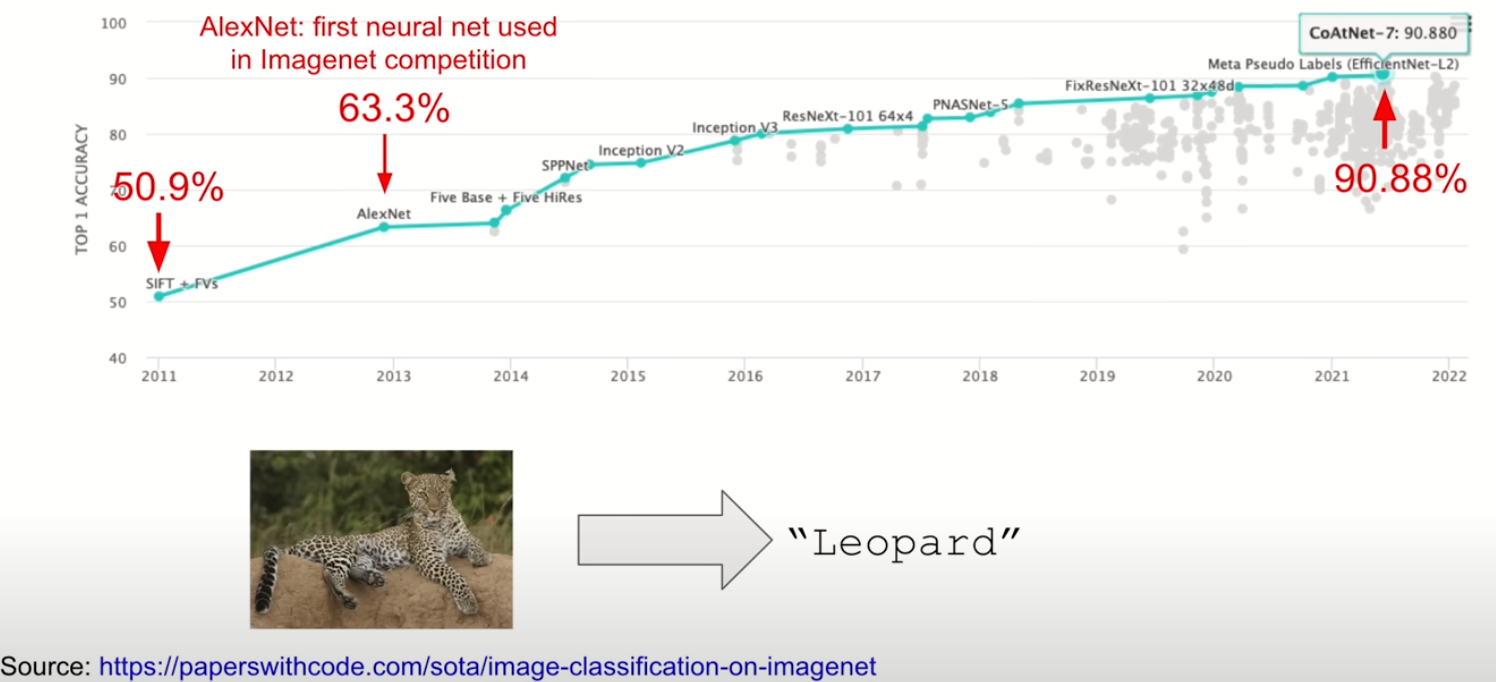

### <font color='blue'>Summary for supervised ML methods</font>

* Prior to 2013 ML methods, such as those reviewed here were the most popular, while neural networks were a niche method.  


* Since 2013 the revolution in ML is driven by the convolutional neural networks that reign in the image classification problems. Advent of GPUs also made standard deep networks easier to train. 


* For problems not involving images neural networks and extremely randomized forests are the most versatile. For very large data set the latter in the form of XGBoost algorithm are the best choice. 